<img src="https://heig-vd.ch/docs/default-source/doc-global-newsletter/2020-slim.svg" alt="Logo HEIG-VD" style="width: 80px;" align="right"/>

# Cours PCD - Labo 1

# Extraction d'attributs pour la détection du spam

## Résumé

Le but de ce travail est de réaliser des expériences de classification d'emails en *spam* ou *ham* (c'est-à-dire non-spam) grâce aux données et au code fourni intégralement dans ce notebook Jupyter.

Votre objectif sera de chercher les meilleurs attributs (*features*) qu'on puisse extraire des emails, ainsi que les classifieurs, afin de maximiser le score F1 de la classification spam/non-spam.  Les classifieurs utilisés seront de la famille Naive Bayes de Scikit-learn.

Veuillez rendre un notebook avec votre meilleure stratégie.  Présentez clairement les options et leurs résultats, et commentez-les brièvement.

*Source* : l'idée du labo vient du [premier notebook de Gan Sie Huai](https://github.com/huai99/Email-Spam-Detection-Python) avec plusieurs changements et mises à jour.

## 1. Obtention des données

Veuillez télécharger l'archive d'emails depuis Cyberlearn.  Ou téléchargez les cinq archives commençant par `20030228_` depuis https://spamassassin.apache.org/old/publiccorpus/.  Décompressez-les dans un dossier de votre choix dont vous indiquerez le chemin relatif dans `path`.

In [191]:
import os
import glob
import numpy as np
import email


In [192]:
path = 'spam_data/'
print(os.getcwd())

import sys
print(sys.executable)


/Users/adamgruber/Documents/PCD/labo1
/opt/homebrew/Caskroom/miniconda/base/envs/spamenv/bin/python


In [193]:
easy_ham_paths = glob.glob(path+'easy_ham/*')
easy_ham_2_paths = glob.glob(path+'easy_ham_2/*')
hard_ham_paths = glob.glob(path+'hard_ham/*')
spam_paths = glob.glob(path+'spam/*')
spam_2_paths = glob.glob(path+'spam_2/*')



In [194]:
def get_email_content(email_path):
    file = open(email_path,encoding='latin1')
    try:
        msg = email.message_from_file(file)
        for part in msg.walk():
            if part.get_content_type() == 'text/plain':
                return part.get_payload() # prints the raw text
    except Exception as e:
        print(e)
        
        
def get_email_content_bulk(email_paths):
    email_contents = []
    counter = 0
    for o in email_paths:
        content = get_email_content(o)
        email_contents.append(content)
        print("update :)" + str(counter))
        counter+= 1
    return email_contents




## 2. Division en *train* et *test*
Le code suivant vous permet de diviser les données en *train* et *test* (sous-ensembles d'entraînement et de test).  Veuillez l'exécuter pour créer ces deux ensembles.

In [195]:
from sklearn.model_selection import train_test_split

In [196]:
ham_path = [easy_ham_paths, easy_ham_2_paths, hard_ham_paths]
spam_path = [spam_paths, spam_2_paths]


### Setup ham

In [197]:
ham_sample = np.array([train_test_split(o) for o in ham_path], dtype=object)

In [198]:
for o in ham_sample:
    print(len(o[0]), len(o[1]))

# First element is train set, second is test set

1875 626
1050 351
188 63


In [199]:
ham_train = np.array([])
ham_test = np.array([])
for o in ham_sample:
    ham_train = np.concatenate((ham_train, o[0]), axis=0)
    ham_test  = np.concatenate((ham_test,  o[1]), axis=0)

In [200]:
ham_train.shape, ham_test.shape

((3113,), (1040,))

### Setup Spam

In [201]:
spam_sample = np.array([train_test_split(o) for o in spam_path], dtype=object)

In [202]:
for o in [train_test_split(o) for o in spam_path]:
    print(len(o[0]), len(o[1]))

375 126
1047 350


In [203]:
spam_train = np.array([])
spam_test = np.array([])
for o in spam_sample:
    spam_train = np.concatenate((spam_train,o[0]),axis=0)
    spam_test = np.concatenate((spam_test,o[1]),axis=0)

In [204]:
spam_train.shape, spam_test.shape

((1422,), (476,))

### Create labels / Mix Ham & Spam mails

In [205]:
ham_train_label = [0]*ham_train.shape[0] # set labels as 0's when it's a ham
spam_train_label = [1]*spam_train.shape[0] # set labels as 1's when it's a spam
x_train = np.concatenate((ham_train,spam_train))
y_train = np.concatenate((ham_train_label,spam_train_label))

In [206]:
ham_test_label = [0]*ham_test.shape[0]
spam_test_label = [1]*spam_test.shape[0]
x_test = np.concatenate((ham_test,spam_test))
y_test = np.concatenate((ham_test_label,spam_test_label))

In [207]:
train_shuffle_index = np.random.permutation(np.arange(0,x_train.shape[0]))
test_shuffle_index = np.random.permutation(np.arange(0,x_test.shape[0]))

In [208]:
x_train = x_train[train_shuffle_index]
y_train = y_train[train_shuffle_index]

In [209]:
x_test = x_test[test_shuffle_index]
y_test = y_test[test_shuffle_index]

In [210]:
x_train = get_email_content_bulk(x_train)
x_test = get_email_content_bulk(x_test)

update :)0
update :)1
update :)2
update :)3
update :)4
update :)5
update :)6
update :)7
update :)8
update :)9
update :)10
update :)11
update :)12
update :)13
update :)14
update :)15
update :)16
update :)17
update :)18
update :)19
update :)20
update :)21
update :)22
update :)23
update :)24
update :)25
update :)26
update :)27
update :)28
update :)29
update :)30
update :)31
update :)32
update :)33
update :)34
update :)35
update :)36
update :)37
update :)38
update :)39
update :)40
update :)41
update :)42
update :)43
update :)44
update :)45
update :)46
update :)47
update :)48
update :)49
update :)50
update :)51
update :)52
update :)53
update :)54
update :)55
update :)56
update :)57
update :)58
update :)59
update :)60
update :)61
update :)62
update :)63
update :)64
update :)65
update :)66
update :)67
update :)68
update :)69
update :)70
update :)71
update :)72
update :)73
update :)74
update :)75
update :)76
update :)77
update :)78
update :)79
update :)80
update :)81
update :)82
update :)83
up

In [211]:
def remove_null(datas,labels):
    not_null_idx = [i for i,o in enumerate(datas) if o is not None]
    return np.array(datas)[not_null_idx],np.array(labels)[not_null_idx]

In [212]:
x_train,y_train = remove_null(x_train,y_train)
x_test,y_test = remove_null(x_test,y_test)

**Question :** combien d'emails y a-t-il dans le jeu d'entraînement et dans le jeu de test ?  Combien de spam et de ham, respectivement ?  Veuillez écrire le code qui fournit les réponses ci-dessous.

#### Combien d'emails y a-t-il dans le jeu d'entraînement et dans le jeu de test (Après le remove des nulls)?

In [213]:
x_train.shape

(3800,)

Il y a 3811 emails

#### Combien de spam et de ham dans le jeu de test (Après remove des nulls)?

In [214]:
print(np.sum(y_train ==1)) # Spam
print(np.sum(y_train == 0)) # Ham

779
3021


On a 774 Spam et 3018 Ham

## 3. Pré-traitement et nettoyage des données

### 3.1 Traitements de bas niveau

In [215]:
import re
import string
from nltk.tokenize import word_tokenize

In [216]:
def remove_hyperlink(word):
    return  re.sub(r"http\S+", "", word)

In [217]:
def to_lower(word):
    result = word.lower()
    return result

In [218]:
def remove_number(word):
    result = re.sub(r'\d+', '', word)
    return result

In [219]:
def remove_punctuation(word):
    result = word.translate(str.maketrans(dict.fromkeys(string.punctuation)))
    return result

In [220]:
def remove_whitespace(word):
    result = word.strip()
    return result

In [221]:
def replace_newline(word):
    return word.replace('\n',' ')

**Votre mission :** dans la fonction suivante, insérer dans le tableau `cleaning_utils` les noms des fonctions de pré-traitement que vous souhaitez utiliser afin d'obtenir le meilleur filtre anti-spam.   Veuillez commenter brièvement les raisons de votre choix.

- On garde les hyperlinks, car souvent les emails spams en contiennent surement plus que les emails ham.
- On garde les majuscules car les emails spam on la tendance d'ecrire EN MAJUSCULE!
- Enlever les nombre est une bonne idée, car les nombres se trouvent partout, que ce soit des prix, des quantités, donc ils sont juste du bruit.
- La ponctuation pourrait contenir plus de "!" lorsqu'il s'agit de mail SPAM, mais je pense qu'on peut quand même enlever la ponctuation car c'est minime
- Les espaces sont important pour différencier les mots, mais ici strip enlève seulement les espaces en trop au début et a la fin du string, ce qui est bon pour nous
- On peut remplacer le retour a la ligne par un espace, ça nous change rien et c'est moins lourd.

In [222]:
def clean_up_pipeline(sentence):
    cleaning_utils = [remove_number, remove_punctuation, remove_whitespace, replace_newline]
    for o in cleaning_utils:
        sentence = o(sentence)
    return sentence

In [223]:
x_train = [clean_up_pipeline(o) for o in x_train]
x_test = [clean_up_pipeline(o) for o in x_test]

### 3.2. Traitements linguistiques avec NLTK

Veuillez installer la librairie NLTK avec Conda ou `pip`, voir instructions à https://www.nltk.org.

In [224]:
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction._stop_words import ENGLISH_STOP_WORDS
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [225]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [226]:
def remove_stop_words(words):
    result = [i for i in words if i not in ENGLISH_STOP_WORDS]
    return result

In [227]:
def word_stemmer(words):
    return [stemmer.stem(o) for o in words]

In [228]:
def word_lemmatizer(words):
    return [lemmatizer.lemmatize(o) for o in words]

**Votre mission :** dans la fonction suivante, insérer dans le tableau `cleaning_utils` les noms des fonctions de traitement linguistique que vous souhaitez utiliser afin d'obtenir le meilleur filtre anti-spam.  Veuillez commenter brièvement les raisons de votre choix.

- On applique forcément le "remove_stop_words" parce que les mots comme "of","a", "an" vont pas nous aider a distinguer un ham d'un spam
- Je pense que le stemmer et le lemmatizer sont bien les 2 (a ne pas utiliser ensemble). Mais je préfère le lemmatizer parce que le lemmatizer peut etre un peu aggresif en réduisant les mots

In [229]:
def clean_token_pipeline(words):
    cleaning_utils = [remove_stop_words, word_lemmatizer]
    for o in cleaning_utils:
        words = o(words)
    return words

**Remarque:** la tokenization peut prendre plusieurs minutes, vu la quantité de données.

In [230]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')


x_train = [word_tokenize(o) for o in x_train]
x_test = [word_tokenize(o) for o in x_test]

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adamgruber/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/adamgruber/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adamgruber/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [231]:
x_train = [clean_token_pipeline(o) for o in x_train]
x_test = [clean_token_pipeline(o) for o in x_test]

In [232]:
x_train = [" ".join(o) for o in x_train]
x_test = [" ".join(o) for o in x_test]

# 4. Extraction des attributs (*feature extraction*)

À cette étape, on transforme les textes des emails en une série d'attributs.  Les méthodes proposées par Scikit-learn permettent de décider quels mots on garde comme attributs, puis les valeurs de chaque attribut pour chaque email.  Résultat : au lieu d'une chaîne de caractères, chaque email est représenté par une suite de nombres (de la même taille pour tous).

**Votre mission** : faire des expériences pour choisir entre les deux méthodes suivantes celle qui aboutira aux meilleurs résultats.

In [233]:
from sklearn.feature_extraction.text import CountVectorizer

In [234]:
vectorizer = CountVectorizer()

In [235]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [236]:
vectorizer = TfidfVectorizer()

Transformation des textes des emails en vecteurs d'attributs.

In [237]:
def convert_to_feature(vectorizer, raw_tokenize_data):
    return vectorizer.transform(raw_tokenize_data)

In [239]:
vectorizer.fit(x_train)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [240]:
x_train_features = convert_to_feature(vectorizer, x_train)
x_test_features  = convert_to_feature(vectorizer, x_test)

## 5. Choix de la méthode de classification et entraînement

Dans cette section, vous allez pouvoir choisir le classifieur.  On vous propose de travailler avec un modèle de type *Naïve Bayes*, à choisir parmi plusieurs variantes disponibles dans Scikit-learn, et qui sont décrites à https://scikit-learn.org/stable/modules/naive_bayes.html.

Voici à titre d'exemple l'utilisation du classifieur *Naïve Bayes Multinomial*.

In [262]:
import sklearn.naive_bayes as nb

In [263]:
clf = nb.GaussianNB()

In [264]:
clf.fit(x_train_features.toarray(), y_train) # entraînement du modèle

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [265]:
clf.score(x_train_features.toarray(),y_train) # score F1 du modèle sur les données d'entraînement

0.9997368421052631

**Votre mission :** essayer plusieurs classifieurs basés sur l'approche *Naïve Bayes* et choisir celui qui aboutit au meilleur score *sur les données de test*, qui sera calculé dans la section suivante.

## 6. Évaluation du classifieur entraîné

Dans cette section, vous allez demander au classifieur de classer les données de test (non vues à l'entraînement), et calculer (grâce aux réponses correctes) plusieurs scores qui mesurent les performances de détection de spam.  Veuillez répondre aux questions posées en fin de section.

In [266]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

In [267]:
y_predict = clf.predict(x_test_features.toarray()) # réponses du système sur les données de test

In [268]:
print("Precision: {:.2f}%".format(100 * precision_score(y_test, y_predict)))
print("Recall:    {:.2f}%".format(100 * recall_score(y_test, y_predict)))
print("F1-score:  {:.2f}%".format(100 * f1_score(y_test, y_predict)))

Precision: 97.22%
Recall:    78.95%
F1-score:  87.14%


In [269]:
confusion_matrix(y_test, y_predict) # affichage élémentaire de la matrice de confusion

array([[1004,    6],
       [  56,  210]])

In [270]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

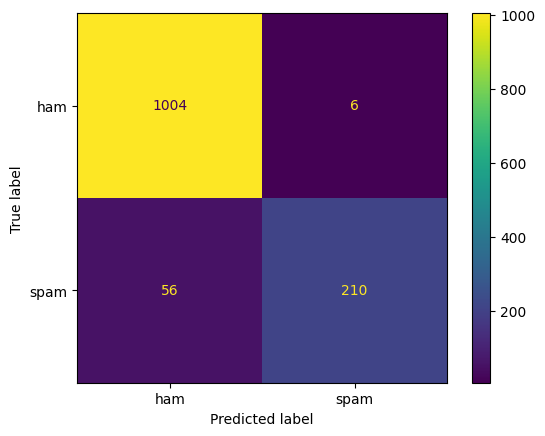

In [271]:
# affichage graphique de la matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_predict, display_labels = ['ham', 'spam']) 
plt.show()

**Veuillez répondre ici** aux questions suivantes :

1. Quel était votre premier score F1 obtenu ?  Quel est votre meilleur score ?  De combien avez-vous progressé grâce à vos choix judicieux ?

2. Quels choix de pré-traitement (section 3) vous ont conduit-e à la meilleure solution ?

3. Quelle représentation des emails vous a conduit-e à la meilleure solution ?

4. Quel classifieur vous a conduit-e à la meilleure solution ?

### Premier F1 score : 55.04%
### Meilleur F1 score : 87.14%
### Progression : 32.10%

### Modifications : J'ai changé le classifier de Multinomial à Gaussian



**Fin du Labo 1.**  Veuillez nettoyer ce notebook en gardant seulement les résultats désirés et vos réponses, l'enregistrer, et le soumettre comme devoir sur Cyberlearn.